<a href="https://colab.research.google.com/github/usumakikai8-bot/DNN4/blob/main/DNN4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#概要

In [1]:
#DNN(最も簡単なDNN（MLP）による鋼材断面カタログ値の推論)を改良して入力特徴量を増やしたものをDNN2とする。
#DNN2のboxの損失の重みを2倍にする。それ以外は、DNN2を変えない。
#evaluateを変更して、正確度(Accuracy)を詳細に出力できるようにした。

正規化をx_minとx_maxではなく、カタログから恣意的に決めてそのリストを用いる。

北川　元輝さんからもらった3階建ての最適化データとカタログを用いて学習する。→ファイルの表記に対応するようにコードを修正する必要がある。


#github

In [2]:
# !git config --global user.name "usumakikai8-bot"
# !git config --global user.email "usumakikai8@gmail.com"

#第1段階セル（ライブラリのインポート、マウント、設定）

In [3]:
# ライブラリのインポート
import csv
import json
import random
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


In [4]:
#google driveのマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%pwd

'/content'

In [6]:
# Drive 上の作業フォルダ。必要なときだけ変更してください。
%cd /content/drive/MyDrive/research/DNN4


/content/drive/MyDrive/research/DNN4


In [7]:
%pwd

'/content/drive/MyDrive/research/DNN4'

path設定は非常に重要だ。フォルダ構成に注意する。

In [8]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
# Google Drive に dataset2 を置いた場合の既定場所。配置が異なる場合はこの2行を変更してください。
DATASET_ROOT = Path('/content/drive/MyDrive/research/dataset2')
CATALOG_ROOT = DATASET_ROOT / 'catalog'
OUTPUT_DIR = PROJECT_ROOT / 'dnn_result'
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_ROOT:', DATASET_ROOT)
print('CATALOG_ROOT:', CATALOG_ROOT)
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/research/DNN4
DATASET_ROOT: /content/drive/MyDrive/research/dataset2
CATALOG_ROOT: /content/drive/MyDrive/research/dataset2/catalog
OUTPUT_DIR: /content/drive/MyDrive/research/DNN4/dnn_result


In [9]:
SEED = 42
BATCH_SIZE = 32
EPOCHS = 500
PATIENCE = 60
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'{DEVICE=}')
missing = [str(DATASET_ROOT / s) for s in ('train', 'val', 'test') if not (DATASET_ROOT / s).is_dir()]
if missing:
    raise FileNotFoundError(f'train/val/test が見つかりません: {missing}')
if not CATALOG_ROOT.is_dir():
    raise FileNotFoundError(f'カタログフォルダが見つかりません: {CATALOG_ROOT}')


DEVICE=device(type='cpu')


#第2セル（各種関数定義、カタログの読み込み）

In [10]:
def seed_everything(seed: int = SEED) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def read_text(path: Path) -> str:
    for encoding in ('utf-8-sig', 'utf-8', 'cp932'):
        try: return path.read_text(encoding=encoding)
        except UnicodeDecodeError: pass
    return path.read_text(encoding='utf-8', errors='replace')

def read_catalog(path: Path, kind: str) -> list[dict]:
    rows = list(csv.DictReader(read_text(path).splitlines()))
    name_col = '断面名'
    cols = ('呼び梁せいH(mm)', '呼び幅B(mm)', '腹板厚tw(mm)', 'フランジ厚tf(mm)') if kind == 'h' else ('呼び柱径D(mm)', '板厚t(mm)')
    if not rows or not {name_col, *cols}.issubset(rows[0]):
        raise ValueError(f'カタログCSVの列が想定と異なります: {path}')
    return [{'name': r[name_col].strip(), 'values': tuple(float(r[c]) for c in cols)} for r in rows]

H_CATALOG = read_catalog(CATALOG_ROOT / '梁H形鋼カタログ.csv', 'h')
BOX_CATALOG = read_catalog(CATALOG_ROOT / '柱角形鋼管カタログ.csv', 'box')
print(f'H catalog: {len(H_CATALOG)}, box catalog: {len(BOX_CATALOG)}')


H catalog: 35, box catalog: 38


#第3セル（データ前処理、データローダーの作成）

In [11]:
# カタログ寸法の正規化範囲（参考・カタログ属性用）

# 柱。パターンB: 余裕を持たせた丸め値を使用する場合（推奨）
column_normalization_params_rounded = {
    "呼び柱径D": {"min": 200.0, "max": 600.0},
    "実柱径D": {"min": 200.0, "max": 600.0},
    "板厚t": {"min": 5.0, "max": 30.0},
    "角部半径r": {"min": 10.0, "max": 75.0},
    "断面積": {"min": 5000.0, "max": 60000.0},
    "単位重量": {"min": 40.0, "max": 450.0},
}

# 梁。パターンB: 余裕を持たせた丸め値を使用する場合（推奨）
beam_norm_params_rounded = {
    "呼び梁深さH": {"min": 100.0, "max": 1000.0},
    "呼び幅B": {"min": 50.0, "max": 450.0},
    "実梁深さH": {"min": 100.0, "max": 1000.0},
    "実幅B": {"min": 50.0, "max": 450.0},
    "腹板厚tw": {"min": 5.0, "max": 25.0},
    "フランジ厚t2": {"min": 5.0, "max": 40.0},
    "角部半径r": {"min": 5.0, "max": 25.0},
    "断面積": {"min": 1000.0, "max": 40000.0},
    "単位重量": {"min": 10.0, "max": 300.0},
}

In [13]:
FILENAME_RE = re.compile(r'^(?P<id>\d+)_3階_X(?P<nx>\d+)_Y(?P<ny>\d+)_荷重(?P<load>[\d.]+)\.csv$')

def table_after_marker(text: str, marker: str):
    lines = text.splitlines()
    try:
        start = next(i for i, line in enumerate(lines) if line.strip() == marker)
        data_at = next(i for i in range(start + 1, len(lines)) if lines[i].strip() == '<data>')
    except StopIteration as exc:
        raise ValueError(f'{marker} または <data> がありません') from exc
    header = next(csv.reader([lines[data_at - 1]]))
    rows = []
    for line in lines[data_at + 1:]:
        if not line.strip() or line.strip().startswith('name='): break
        rows.append(next(csv.reader([line])))
    return header, rows

def nominal_to_catalog_name(nominal: str, kind: str) -> str:
    name = nominal.strip()
    catalog = H_CATALOG if kind == 'h' else BOX_CATALOG
    if name not in {r['name'] for r in catalog}: raise ValueError(f'カタログにない断面名です: {name}')
    return name

def parse_targets(path: Path) -> dict[str, tuple[str, str]]:
    text = read_text(path); result = {}
    _, rows = table_after_marker(text, 'name=S柱断面')
    for row in rows:
        floor, symbol, _, section = row[:4]
        result[f'column:{floor.strip()}:{symbol.strip()}'] = ('box', nominal_to_catalog_name(section, 'box'))
    header, rows = table_after_marker(text, 'name=梁断面リスト')
    for row in rows:
        floor = row[0].strip()
        for symbol, section in zip(header[1:], row[1:]):
            if section.strip(): result[f'beam:{floor}:{symbol.strip()}'] = ('h', nominal_to_catalog_name(section, 'h'))
    return result

def features_from_name(path: Path) -> np.ndarray:
    m = FILENAME_RE.fullmatch(path.name)
    if not m: raise ValueError(f'想定外のファイル名です: {path.name}')
    nx, ny, load = float(m['nx']), float(m['ny']), float(m['load'])
    _, rows = table_after_marker(read_text(path), 'name=スパン割')
    spans = {r[0].strip(): [float(v) for v in r[1:] if v.strip()] for r in rows}
    lx, ly = float(np.mean(spans['X'])), float(np.mean(spans['Y']))
    return np.asarray([nx, ny, lx, ly, load, nx*lx*ny*ly, lx/ly, nx*lx, ny*ly], dtype=np.float32)

@dataclass
class Sample:
    file_name: str
    x: np.ndarray
    targets: dict[str, tuple[str, str]]

def load_split(split: str) -> list[Sample]:
    paths = sorted((DATASET_ROOT / split).glob('*.csv'))
    if not paths: raise FileNotFoundError(f'{split} にCSVがありません')
    samples = [Sample(p.name, features_from_name(p), parse_targets(p)) for p in paths]
    print(f'{split}: {len(samples)} files')
    return samples

seed_everything()
train_samples, val_samples, test_samples = (load_split(s) for s in ('train', 'val', 'test'))
SLOTS = sorted({key for sample in train_samples for key in sample.targets})
SLOT_TYPES = [next(sample.targets[slot][0] for sample in train_samples if slot in sample.targets) for slot in SLOTS]
H_TO_ID = {r['name']: i for i, r in enumerate(H_CATALOG)}
BOX_TO_ID = {r['name']: i for i, r in enumerate(BOX_CATALOG)}
feature_mean = np.stack([s.x for s in train_samples]).mean(axis=0)
feature_std = np.stack([s.x for s in train_samples]).std(axis=0).clip(1e-6)
# 入力特徴量の固定Min-Max範囲。データセット統計から範囲を再推定しません。
# nx, ny, X/Y平均スパン(mm),荷重(kN/m2),床面積(mm2),X/Y比,X/Y全長(mm)
FEATURE_NORMALIZATION = [(1,5),(1,5),(5000,12000),(5000,12000),(6,9),(25_000_000,3_000_000_000),(0.3,3),(5000,60000),(5000,60000)]
feature_min = np.asarray([v[0] for v in FEATURE_NORMALIZATION], dtype=np.float32)
feature_max = np.asarray([v[1] for v in FEATURE_NORMALIZATION], dtype=np.float32)
feature_range = feature_max - feature_min

class SectionDataset(Dataset):
    def __init__(self, samples: list[Sample]): self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, index):
        sample = self.samples[index]; y_h, y_box = [], []
        for slot, kind in zip(SLOTS, SLOT_TYPES):
            if slot not in sample.targets:
                # 建物に存在しない通り・方向の断面は損失計算から除外する
                (y_h if kind == 'h' else y_box).append(-100)
                continue
            _, name = sample.targets[slot]
            (y_h if kind == 'h' else y_box).append((H_TO_ID if kind == 'h' else BOX_TO_ID)[name])
        x = np.clip((sample.x - feature_min) / feature_range, 0.0, 1.0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y_h, dtype=torch.long), torch.tensor(y_box, dtype=torch.long), sample.file_name

train_loader = DataLoader(SectionDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SectionDataset(val_samples), batch_size=BATCH_SIZE)
test_loader = DataLoader(SectionDataset(test_samples), batch_size=BATCH_SIZE)
N_H_SLOTS = sum(k == 'h' for k in SLOT_TYPES); N_BOX_SLOTS = sum(k == 'box' for k in SLOT_TYPES)
print(f'features={len(feature_mean)}, H slots={N_H_SLOTS}, box slots={N_BOX_SLOTS}')


train: 960 files
val: 120 files
test: 120 files
features=9, H slots=24, box slots=12


#第4セル（DNNモデルの定義とインスタンス化）

In [14]:
# 1. ニューラルネットワークの構造定義 (SimpleDNN)
class SimpleDNN(nn.Module):
    """最も簡単な多層パーセプトロン（MLP）によるモデル"""
    def __init__(self, n_features: int, n_h_slots: int, n_box_slots: int, n_h_catalog: int, n_box_catalog: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
        )
        self.h_head = nn.Linear(128, n_h_slots * n_h_catalog)
        self.box_head = nn.Linear(128, n_box_slots * n_box_catalog)

        self.n_h_slots = n_h_slots
        self.n_h_catalog = n_h_catalog
        self.n_box_slots = n_box_slots
        self.n_box_catalog = n_box_catalog

#2. 順伝播処理 (forward)
    def forward(self, x):
        h = self.net(x)
        logits_h = self.h_head(h).view(-1, self.n_h_slots, self.n_h_catalog)
        logits_box = self.box_head(h).view(-1, self.n_box_slots, self.n_box_catalog)
        return logits_h, logits_box

#3. モデルのインスタンス化とパラメータ数の確認
model = SimpleDNN(
    n_features=len(feature_mean),
    n_h_slots=N_H_SLOTS,
    n_box_slots=N_BOX_SLOTS,
    n_h_catalog=len(H_CATALOG),
    n_box_catalog=len(BOX_CATALOG)
).to(DEVICE)
print(f'parameters={sum(p.numel() for p in model.parameters()):,}')

parameters=184,976


#第5セル（評価関数、学習ループ、グラフ描画）

epoch=001 train_loss=7.0160 val_loss=6.7077 val_acc=0.263
epoch=020 train_loss=2.8169 val_loss=2.9528 val_acc=0.519
epoch=040 train_loss=2.3815 val_loss=2.5954 val_acc=0.568
epoch=060 train_loss=2.2896 val_loss=2.5489 val_acc=0.571
epoch=080 train_loss=2.2268 val_loss=2.5300 val_acc=0.583
epoch=100 train_loss=2.1815 val_loss=2.5148 val_acc=0.584
epoch=120 train_loss=2.1429 val_loss=2.4889 val_acc=0.588
epoch=140 train_loss=2.1037 val_loss=2.4882 val_acc=0.591
epoch=160 train_loss=2.0884 val_loss=2.4840 val_acc=0.589
epoch=180 train_loss=2.0756 val_loss=2.4854 val_acc=0.592
epoch=200 train_loss=2.0623 val_loss=2.4823 val_acc=0.592
epoch=220 train_loss=2.0493 val_loss=2.4796 val_acc=0.596
epoch=240 train_loss=2.0377 val_loss=2.4787 val_acc=0.591
epoch=260 train_loss=2.0328 val_loss=2.4758 val_acc=0.593
Early stopping at epoch 268; best val loss=2.4745


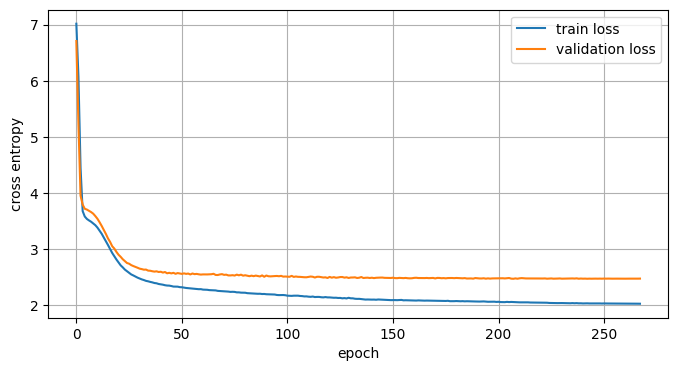

In [15]:
# 1. 評価・推論処理 (evaluate)
# 1. 評価・推論処理 (evaluate)
@torch.no_grad()
def evaluate(loader, export_rows=False):
    model.eval()

    total, correct, full_correct, loss_sum = 0, 0, 0, 0.0

    # 梁・柱の正解数
    h_total, h_correct = 0, 0
    box_total, box_correct = 0, 0

    # 階ごとの正解数
    floor_stats = {}

    records = []

    for x, y_h, y_box, names in loader:
        x, y_h, y_box = x.to(DEVICE), y_h.to(DEVICE), y_box.to(DEVICE)

        logits_h, logits_box = model(x)

        loss_h = nn.functional.cross_entropy(
            logits_h.transpose(1, 2), y_h, ignore_index=-100
        )
        loss_box = nn.functional.cross_entropy(
            logits_box.transpose(1, 2), y_box, ignore_index=-100
        )

        # 通常の重み付け（柱Loss×2は使用しない）
        loss = loss_h + loss_box

        pred_h = logits_h.argmax(-1)
        pred_box = logits_box.argmax(-1)

        # --------------------------------
        # 全スロットのAccuracy
        # --------------------------------
        all_pred = torch.cat([pred_h, pred_box], dim=1)
        all_true = torch.cat([y_h, y_box], dim=1)

        valid = all_true.ne(-100)
        matches = all_pred.eq(all_true) & valid
        correct += matches.sum().item()
        total += valid.sum().item()

        # 建物に存在するスロットだけで完全一致を判定
        full_correct += (matches | ~valid).all(1).sum().item()

        # --------------------------------
        # 梁（H）のAccuracy
        # --------------------------------
        h_valid = y_h.ne(-100)
        h_correct += (pred_h.eq(y_h) & h_valid).sum().item()
        h_total += h_valid.sum().item()

        # --------------------------------
        # 柱（BOX）のAccuracy
        # --------------------------------
        box_valid = y_box.ne(-100)
        box_correct += (pred_box.eq(y_box) & box_valid).sum().item()
        box_total += box_valid.sum().item()

        # --------------------------------
        # 階ごとのAccuracy
        # --------------------------------
        for slot_idx, (slot, kind) in enumerate(zip(SLOTS, SLOT_TYPES)):

            # slot名から階を取得
            if ':' in slot:
                floor = slot.split(':')[1]
            else:
                floor = slot

            if floor not in floor_stats:
                floor_stats[floor] = {
                    'correct': 0,
                    'total': 0
                }

            if kind == 'h':
                pred = pred_h[:, sum(
                    1 for s, k in zip(SLOTS[:slot_idx], SLOT_TYPES[:slot_idx])
                    if k == 'h'
                )]

                true = y_h[:, sum(
                    1 for s, k in zip(SLOTS[:slot_idx], SLOT_TYPES[:slot_idx])
                    if k == 'h'
                )]

            else:
                pred = pred_box[:, sum(
                    1 for s, k in zip(SLOTS[:slot_idx], SLOT_TYPES[:slot_idx])
                    if k == 'box'
                )]

                true = y_box[:, sum(
                    1 for s, k in zip(SLOTS[:slot_idx], SLOT_TYPES[:slot_idx])
                    if k == 'box'
                )]

            active = true.ne(-100)
            floor_stats[floor]['correct'] += (pred.eq(true) & active).sum().item()
            floor_stats[floor]['total'] += active.sum().item()

        loss_sum += loss.item() * len(names)

        # --------------------------------
        # CSV出力用データ
        # --------------------------------
        if export_rows:
            for b, name in enumerate(names):

                hi = bi = 0

                for slot, kind in zip(SLOTS, SLOT_TYPES):

                    if kind == 'h':
                        p = pred_h[b, hi].item()
                        t = y_h[b, hi].item()
                        hi += 1
                        catalog = H_CATALOG

                    else:
                        p = pred_box[b, bi].item()
                        t = y_box[b, bi].item()
                        bi += 1
                        catalog = BOX_CATALOG

                    # -100 はその建物に存在しないスロットを示すため、出力対象外
                    if t == -100:
                        continue
                    if not (0 <= t < len(catalog)):
                        raise ValueError(
                            f'Invalid target index: file={name}, slot={slot}, '
                            f'target_id={t}, catalog_size={len(catalog)}, type={kind}'
                        )
                    if not (0 <= p < len(catalog)):
                        raise ValueError(
                            f'Invalid prediction index: file={name}, slot={slot}, '
                            f'predicted_id={p}, catalog_size={len(catalog)}, type={kind}'
                        )
                    records.append({
                        'file_name': name,
                        'slot': slot,
                        'section_type': kind,
                        'predicted_catalog': catalog[p]['name'],
                        'true_catalog': catalog[t]['name'],
                        'is_correct': p == t
                    })

    n_files = len(loader.dataset)

    return {
        'loss': loss_sum / n_files,

        # 全体
        'slot_accuracy': correct / max(total, 1),

        # 梁
        'h_accuracy': h_correct / max(h_total, 1),

        # 柱
        'box_accuracy': box_correct / max(box_total, 1),

        # 建物完全一致
        'building_exact_match': full_correct / n_files,

        # 階ごとの統計
        'floor_stats': floor_stats,

        'records': records
    }

#2. オプティマイザとスケジューラの準備
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
best_state, best_val, wait = None, float('inf'), 0
history = {'train_loss': [], 'val_loss': [], 'val_slot_accuracy': []}

#3. 学習ループ（Training Loop）
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for x, y_h, y_box, _ in train_loader:
        x, y_h, y_box = x.to(DEVICE), y_h.to(DEVICE), y_box.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits_h, logits_box = model(x)
        #loss = nn.functional.cross_entropy(logits_h.transpose(1, 2), y_h) + nn.functional.cross_entropy(logits_box.transpose(1, 2), y_box)
                # H梁とBOX柱の損失を別々に計算
        loss_h = nn.functional.cross_entropy(
            logits_h.transpose(1, 2), y_h, ignore_index=-100
        )
        loss_box = nn.functional.cross_entropy(
            logits_box.transpose(1, 2), y_box, ignore_index=-100
        )

        # 通常の重み付け（柱Loss×2は使用しない）
        loss = loss_h + loss_box
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(x)
    val = evaluate(val_loader)
    train_loss /= len(train_loader.dataset)
    scheduler.step(val['loss'])
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val['loss'])
    history['val_slot_accuracy'].append(val['slot_accuracy'])
    if val['loss'] < best_val:
        best_val, wait = val['loss'], 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1
    if epoch == 1 or epoch % 20 == 0:
        print(f'epoch={epoch:03d} train_loss={train_loss:.4f} val_loss={val["loss"]:.4f} val_acc={val["slot_accuracy"]:.3f}')
    if wait >= PATIENCE:
        print(f'Early stopping at epoch {epoch}; best val loss={best_val:.4f}')
        break

#4. 最良モデルの復元と学習曲線のプロット
model.load_state_dict(best_state)
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('epoch'); plt.ylabel('cross entropy'); plt.legend(); plt.grid(); plt.show()

#第6セル（テストデータの評価、ファイル保存）

In [16]:
# 1. テストデータの評価と結果表示
test_result = evaluate(test_loader, export_rows=True)

print("=" * 50)
print("Test Results")
print("=" * 50)

print(f"Loss                  : {test_result['loss']:.4f}")
print(f"Slot Accuracy         : {test_result['slot_accuracy']:.4f}")
print(f"H (Beam) Accuracy     : {test_result['h_accuracy']:.4f}")
print(f"BOX (Column) Accuracy : {test_result['box_accuracy']:.4f}")
print(f"Building Exact Match  : {test_result['building_exact_match']:.4f}")

print("\n" + "=" * 50)
print("Accuracy by Floor")
print("=" * 50)

for floor, stats in test_result['floor_stats'].items():
    accuracy = stats['correct'] / stats['total']
    print(
        f"{floor:>4s} : "
        f"{accuracy:.4f} "
        f"({stats['correct']}/{stats['total']})"
    )

#2. 予測結果のCSVファイルへの書き出し
predictions = pd.DataFrame(test_result['records'])
pred_path = OUTPUT_DIR / 'test_catalog_predictions.csv'
predictions.to_csv(pred_path, index=False, encoding='utf-8-sig')

#3. チェックポイント（学習済みモデル等）の保存
checkpoint = {
    'model_state_dict': model.state_dict(),
    'feature_min': feature_min,  # 最小値を保存
    'feature_max': feature_max,
    'feature_normalization': FEATURE_NORMALIZATION,
    'slots': SLOTS,
    'slot_types': SLOT_TYPES,
    'h_catalog': H_CATALOG,
    'box_catalog': BOX_CATALOG,
}
torch.save(checkpoint, OUTPUT_DIR / 'best_section_dnn.pt')

#4. 完了メッセージと予測結果プレビューの表示
print(f'Saved: {pred_path}')
print(predictions.head(20).to_string(index=False))

Test Results
Loss                  : 2.5180
Slot Accuracy         : 0.5675
H (Beam) Accuracy     : 0.6179
BOX (Column) Accuracy : 0.4854
Building Exact Match  : 0.0167

Accuracy by Floor
 2FL : 0.5508 (694/1260)
 3FL : 0.5865 (739/1260)
 RFL : 0.5987 (467/780)
 1FL : 0.5104 (245/480)
Saved: /content/drive/MyDrive/research/DNN4/dnn_result/test_catalog_predictions.csv
            file_name          slot section_type predicted_catalog      true_catalog  is_correct
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GX1            h H-450x200x9x14x13 H-450x200x9x14x13        True
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GX2            h H-450x200x9x14x13 H-450x200x9x14x13        True
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GX3            h H-450x200x9x14x13 H-450x200x9x14x13        True
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GX4            h H-450x200x9x14x13 H-450x200x9x14x13        True
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GY1            h H-450x200x9x14x13 H-450x200x9x14x13        True
0030_3階_X4_Y3_荷重8.csv  beam:2FL:GY2            h 

#第7セル（結果をグラフで可視化）

In [17]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 45.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=9fbe2399376b18ba700373af679573b7985aaa609bfce99d9641534591a8da9a
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


In [18]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from google.colab import files
#コード中で、
import japanize_matplotlib

#上書きされたあとで、
japanize_matplotlib.japanize()




##dataframeを作る

In [19]:
#2. 予測結果のCSVファイルへの書き出し
predictions = pd.DataFrame(test_result['records'])
#predictions.head(20)
predictions

,file_name,slot,section_type,predicted_catalog,true_catalog,is_correct
0,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX1,h,H-450x200x9x14x13,H-450x200x9x14x13,True
1,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX2,h,H-450x200x9x14x13,H-450x200x9x14x13,True
2,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX3,h,H-450x200x9x14x13,H-450x200x9x14x13,True
3,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX4,h,H-450x200x9x14x13,H-450x200x9x14x13,True
4,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GY1,h,H-450x200x9x14x13,H-450x200x9x14x13,True
...,...,...,...,...,...,...
3775,1189_3階_X5_Y4_荷重6.5.csv,column:2FL:C4,box,□-350x350x12x30,□-350x350x16x40,False
3776,1189_3階_X5_Y4_荷重6.5.csv,column:3FL:C1,box,□-250x250x9x22.5,□-250x250x9x22.5,True
3777,1189_3階_X5_Y4_荷重6.5.csv,column:3FL:C2,box,□-300x300x12x30,□-250x250x9x22.5,False
3778,1189_3階_X5_Y4_荷重6.5.csv,column:3FL:C3,box,□-350x350x12x30,□-350x350x12x30,True


In [20]:
FILENAME_RE = re.compile(
    r"^(?P<id>\d+)_(?P<floor>\d+)階_"
    r"X(?P<x_spans>\d+)_Y(?P<y_spans>\d+)_"
    r"荷重(?P<load>[\d.]+)\.csv$"
)

def parse_filename(filename):
    match = FILENAME_RE.fullmatch(str(filename))
    if match is None:
        return pd.Series({
            "階数": pd.NA,
            "xスパン数": pd.NA,
            "yスパン数": pd.NA,
            "荷重": pd.NA,
        })

    return pd.Series({
        "階数": int(match["floor"]),
        "xスパン数": int(match["x_spans"]),
        "yスパン数": int(match["y_spans"]),
        "荷重": float(match["load"]),
    })

# file_name 列から情報を読み取り、predictions に追加
filename_info = predictions["file_name"].apply(parse_filename)
predictions = pd.concat([predictions, filename_info], axis=1)

predictions.head()

,file_name,slot,section_type,predicted_catalog,true_catalog,is_correct,階数,xスパン数,yスパン数,荷重
0,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX1,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0
1,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX2,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0
2,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX3,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0
3,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX4,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0
4,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GY1,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0


In [21]:

def parse_catalog_to_columns(catalog_str):
    """断面名を [shape, H, D, B, tw, tf, t] に分解する。"""
    empty = [None, None, None, None, None, None, None]

    if not isinstance(catalog_str, str):
        return pd.Series(empty)

    catalog_str = catalog_str.strip()

    # H形鋼: H-せいx幅xtwxtfx角部半径
    # 例: H-450x200x9x14x13
    h_match = re.fullmatch(
        r"H-(\d+(?:\.\d+)?)x(\d+(?:\.\d+)?)x"
        r"(\d+(?:\.\d+)?)x(\d+(?:\.\d+)?)(?:x\d+(?:\.\d+)?)?",
        catalog_str,
        re.IGNORECASE,
    )
    if h_match:
        h, b, tw, tf = map(float, h_match.groups())
        return pd.Series(["H", h, None, b, tw, tf, None])

    # 角形鋼管: □-D x B x t x 角部半径
    # 例: □-350x350x12x30
    box_match = re.fullmatch(
        r"(?:□|BOX)-(\d+(?:\.\d+)?)x(\d+(?:\.\d+)?)x"
        r"(\d+(?:\.\d+)?)(?:x\d+(?:\.\d+)?)?",
        catalog_str,
        re.IGNORECASE,
    )
    if box_match:
        d, b, t = map(float, box_match.groups())
        return pd.Series(["BOX", None, d, b, None, None, t])

    return pd.Series(empty)


base_cols = ["shape", "H", "D", "B", "tw", "tf", "t"]
parsed_cols = (
    [f"pred_{c}" for c in base_cols]
    + [f"true_{c}" for c in base_cols]
)

# 既に同名列があれば削除してから作り直す
predictions = predictions.drop(columns=parsed_cols, errors="ignore")

pred_parsed = predictions["predicted_catalog"].apply(parse_catalog_to_columns)
pred_parsed.columns = [f"pred_{c}" for c in base_cols]

true_parsed = predictions["true_catalog"].apply(parse_catalog_to_columns)
true_parsed.columns = [f"true_{c}" for c in base_cols]

predictions = pd.concat(
    [predictions, pred_parsed, true_parsed],
    axis=1,
)

predictions.head(20)

,file_name,slot,section_type,predicted_catalog,true_catalog,is_correct,階数,xスパン数,yスパン数,荷重,...,pred_tw,pred_tf,pred_t,true_shape,true_H,true_D,true_B,true_tw,true_tf,true_t
0,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX1,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
1,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX2,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
2,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX3,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
3,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GX4,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
4,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GY1,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
5,0030_3階_X4_Y3_荷重8.csv,beam:2FL:GY2,h,H-450x200x9x14x13,H-450x200x9x14x13,True,3.0,4.0,3.0,8.0,...,9.0,14.0,NaN,H,450.0,NaN,200.0,9.0,14.0,NaN
6,0030_3階_X4_Y3_荷重8.csv,beam:3FL:GX1,h,H-400x200x8x13x13,H-400x200x8x13x13,True,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,400.0,NaN,200.0,8.0,13.0,NaN
7,0030_3階_X4_Y3_荷重8.csv,beam:3FL:GX2,h,H-400x200x8x13x13,H-400x200x8x13x13,True,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,400.0,NaN,200.0,8.0,13.0,NaN
8,0030_3階_X4_Y3_荷重8.csv,beam:3FL:GX3,h,H-400x200x8x13x13,H-400x200x8x13x13,True,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,400.0,NaN,200.0,8.0,13.0,NaN
9,0030_3階_X4_Y3_荷重8.csv,beam:3FL:GX4,h,H-400x200x8x13x13,H-400x200x8x13x13,True,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,400.0,NaN,200.0,8.0,13.0,NaN


In [22]:
# is_correct が False の行のみを抽出して新しい DataFrame を作成
incorrect_predictions = predictions[predictions["is_correct"] == False].copy()

# もし is_correct が論理値（Boolean）型ではなく文字列の "false" や "False" である場合は、以下のように条件を指定してください
# incorrect_predictions = predictions[predictions["is_correct"].astype(str).str.lower() == "false"].copy()
incorrect_predictions

,file_name,slot,section_type,predicted_catalog,true_catalog,is_correct,階数,xスパン数,yスパン数,荷重,...,pred_tw,pred_tf,pred_t,true_shape,true_H,true_D,true_B,true_tw,true_tf,true_t
12,0030_3階_X4_Y3_荷重8.csv,beam:RFL:GX1,h,H-400x200x8x13x13,H-350x175x7x11x13,False,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,350.0,NaN,175.0,7.0,11.0,NaN
13,0030_3階_X4_Y3_荷重8.csv,beam:RFL:GX2,h,H-400x200x8x13x13,H-350x175x7x11x13,False,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,350.0,NaN,175.0,7.0,11.0,NaN
14,0030_3階_X4_Y3_荷重8.csv,beam:RFL:GX3,h,H-400x200x8x13x13,H-350x175x7x11x13,False,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,350.0,NaN,175.0,7.0,11.0,NaN
15,0030_3階_X4_Y3_荷重8.csv,beam:RFL:GX4,h,H-400x200x8x13x13,H-350x175x7x11x13,False,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,350.0,NaN,175.0,7.0,11.0,NaN
16,0030_3階_X4_Y3_荷重8.csv,beam:RFL:GY1,h,H-400x200x8x13x13,H-350x175x7x11x13,False,3.0,4.0,3.0,8.0,...,8.0,13.0,NaN,H,350.0,NaN,175.0,7.0,11.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,1189_3階_X5_Y4_荷重6.5.csv,column:2FL:C1,box,□-250x250x12x30,□-250x250x9x22.5,False,3.0,5.0,4.0,6.5,...,NaN,NaN,12.0,BOX,NaN,250.0,250.0,NaN,NaN,9.0
3773,1189_3階_X5_Y4_荷重6.5.csv,column:2FL:C2,box,□-300x300x19x47.5,□-300x300x12x30,False,3.0,5.0,4.0,6.5,...,NaN,NaN,19.0,BOX,NaN,300.0,300.0,NaN,NaN,12.0
3774,1189_3階_X5_Y4_荷重6.5.csv,column:2FL:C3,box,□-300x300x19x47.5,□-350x350x12x30,False,3.0,5.0,4.0,6.5,...,NaN,NaN,19.0,BOX,NaN,350.0,350.0,NaN,NaN,12.0
3775,1189_3階_X5_Y4_荷重6.5.csv,column:2FL:C4,box,□-350x350x12x30,□-350x350x16x40,False,3.0,5.0,4.0,6.5,...,NaN,NaN,12.0,BOX,NaN,350.0,350.0,NaN,NaN,16.0


##↑ここまででdataframeの作成は完了。

In [23]:
print(predictions.head(20))

                file_name           slot section_type  predicted_catalog  \
0   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GX1            h  H-450x200x9x14x13   
1   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GX2            h  H-450x200x9x14x13   
2   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GX3            h  H-450x200x9x14x13   
3   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GX4            h  H-450x200x9x14x13   
4   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GY1            h  H-450x200x9x14x13   
5   0030_3階_X4_Y3_荷重8.csv   beam:2FL:GY2            h  H-450x200x9x14x13   
6   0030_3階_X4_Y3_荷重8.csv   beam:3FL:GX1            h  H-400x200x8x13x13   
7   0030_3階_X4_Y3_荷重8.csv   beam:3FL:GX2            h  H-400x200x8x13x13   
8   0030_3階_X4_Y3_荷重8.csv   beam:3FL:GX3            h  H-400x200x8x13x13   
9   0030_3階_X4_Y3_荷重8.csv   beam:3FL:GX4            h  H-400x200x8x13x13   
10  0030_3階_X4_Y3_荷重8.csv   beam:3FL:GY1            h  H-400x200x8x13x13   
11  0030_3階_X4_Y3_荷重8.csv   beam:3FL:GY2            h  H-400x200x8x13x13   
12  0030_3階_

##H型鋼の梁とxスパン数のグラフ作成



Googleドライブに保存しました: /content/drive/MyDrive/research/DNN/Graphs/Xスパン数ごとのH形鋼の縦寸法（予測値 vs 正解値）.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

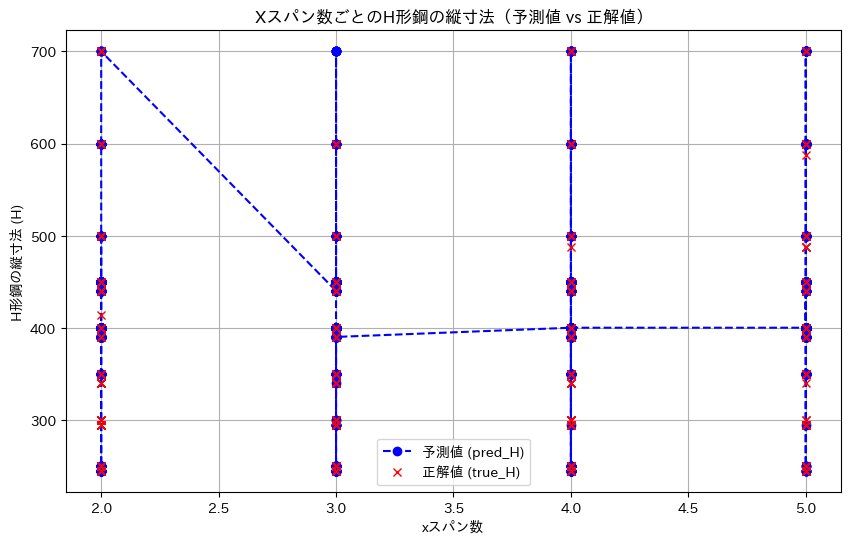

In [25]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# 1. Googleドライブ側の保存先ディレクトリを指定
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)

# 2. グラフのタイトル
graph_title = 'Xスパン数ごとのH形鋼の縦寸法（予測値 vs 正解値）'

# 2. グラフの描画処理
df_h = predictions[predictions['section_type'] == 'h'].sort_values('xスパン数').copy()

plt.figure(figsize=(10, 6))

plt.plot(
    df_h['xスパン数'],
    df_h['pred_H'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_H)',
)

plt.plot(
    df_h['xスパン数'],
    df_h['true_H'],
    marker='x',
    linestyle='None',
    color='red',
    label='正解値 (true_H)',
)

plt.xlabel('xスパン数')
plt.ylabel('H形鋼の縦寸法 (H)')
plt.title(f'{graph_title}')
plt.legend()
plt.grid(True)

# 3. ファイル名の定義
file_name = f'{graph_title}.png'

# 4. Googleドライブに保存
drive_path = os.path.join(save_dir, file_name)
plt.savefig(drive_path, bbox_inches='tight')
print(f'Googleドライブに保存しました: {drive_path}')

# 5. Colabサーバー上の一時保存用パス
plt.savefig(file_name, bbox_inches='tight')

# 6. ご自身のPCへダウンロード
files.download(file_name)

plt.show()

##H型鋼の梁とxスパン数のグラフ作成（一点だけ）

Googleドライブに保存しました: /content/drive/MyDrive/research/DNN/Graphs/Xスパン数ごとのH形鋼の縦寸法（予測値 vs 正解値）.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

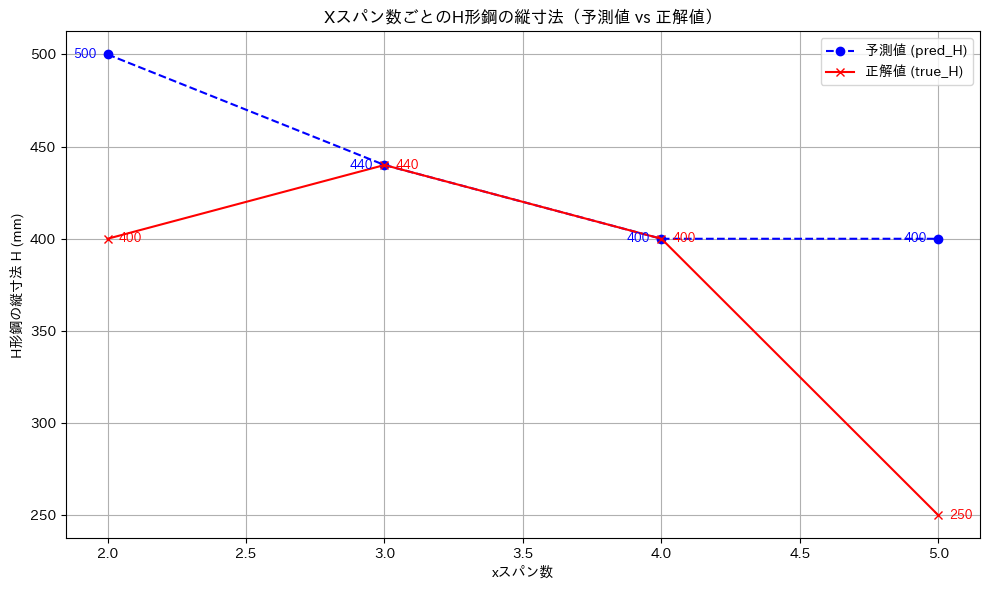

In [39]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# 1. Googleドライブ側の保存先ディレクトリを指定
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)

# 2. グラフのタイトル
graph_title = 'Xスパン数ごとのH形鋼の縦寸法（予測値 vs 正解値）'

# 3. xスパン数ごとに1点だけ残す
df_h = (
    predictions[
        predictions['section_type'] == 'h'
    ]
    .sort_values('xスパン数')
    .drop_duplicates(subset=['xスパン数'])
    .copy()
)

# 4. グラフの描画
plt.figure(figsize=(10, 6))

# 予測値
plt.plot(
    df_h['xスパン数'],
    df_h['pred_H'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_H)',
)

# 正解値
plt.plot(
    df_h['xスパン数'],
    df_h['true_H'],
    marker='x',
    linestyle='-',
    color='red',
    label='正解値 (true_H)',
)

# 5. 各点に実際の寸法を表示
for _, row in df_h.iterrows():

    # 予測値
    plt.annotate(
        f"{row['pred_H']:.0f}",
        xy=(row['xスパン数'], row['pred_H']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # 正解値
    plt.annotate(
        f"{row['true_H']:.0f}",
        xy=(row['xスパン数'], row['true_H']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )

plt.xlabel('xスパン数')
plt.ylabel('H形鋼の縦寸法 H (mm)')
plt.title(graph_title)
plt.legend()
plt.grid(True)
plt.tight_layout()

# 6. ファイル名の定義
file_name = f'{graph_title}.png'

# 7. Googleドライブに保存
drive_path = os.path.join(save_dir, file_name)
plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)
print(f'Googleドライブに保存しました: {drive_path}')

# 8. Colabサーバー上にも保存
local_path = os.path.join('/content', file_name)
plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

# 9. PCへダウンロード
files.download(local_path)

plt.show()

###不正解のもののみをグラフにする。

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

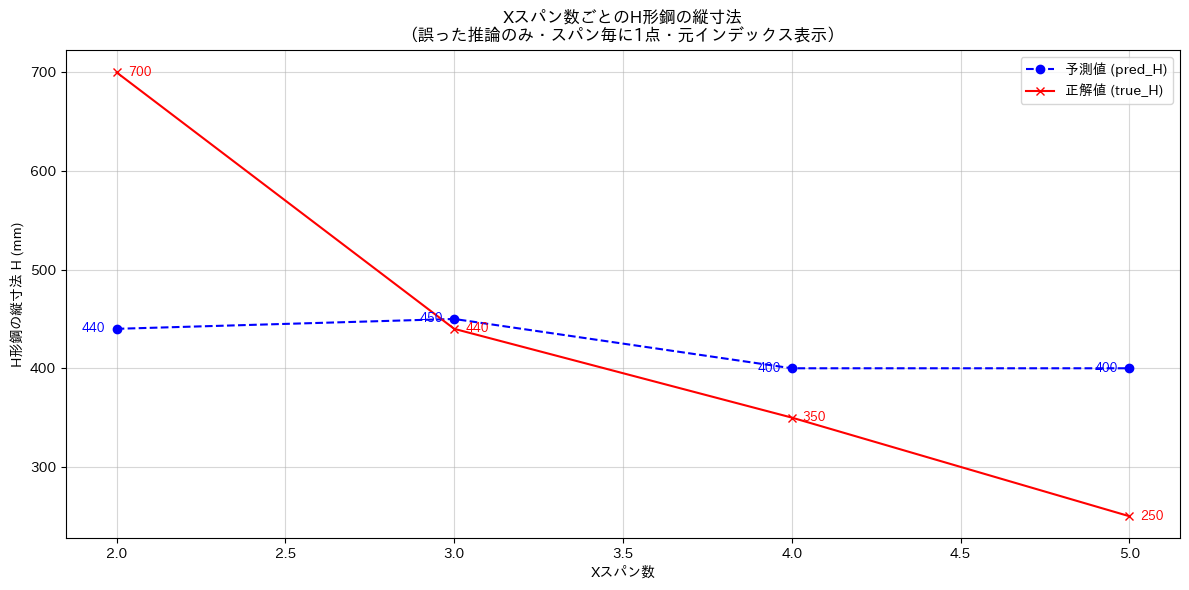

保存しました：/content/drive/MyDrive/research/DNN/Graphs/Xスパン数ごとのH形鋼の縦寸法_誤推論のみ_スパン毎に1点_元インデックス表示.png


In [37]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. 保存先ディレクトリの指定と作成
# ============================================================
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 2. H形鋼の誤推論データを抽出
#    ・section_type == 'h'
#    ・xスパン数で昇順ソート
#    ・各xスパン数につき1件だけ残す
# ============================================================
df_h = (
    incorrect_predictions[
        incorrect_predictions['section_type'] == 'h'
    ]
    .sort_values('xスパン数')
    .drop_duplicates(subset=['xスパン数'])
    .copy()
)


# ============================================================
# 3. グラフ設定
# ============================================================

# グラフタイトル
graph_title = (
    'Xスパン数ごとのH形鋼の縦寸法\n'
    '（誤った推論のみ・スパン毎に1点・元インデックス表示）'
)

# インデックス番号を表示する際のX方向オフセット
offset_x = 0.05

# グラフ作成
plt.figure(figsize=(12, 6))


# ============================================================
# 4. 予測値のプロット
# ============================================================
plt.plot(
    df_h['xスパン数'],
    df_h['pred_H'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_H)',
)


# ============================================================
# 5. 正解値のプロット
# ============================================================
plt.plot(
    df_h['xスパン数'],
    df_h['true_H'],
    marker='x',
    linestyle='-',
    color='red',
    label='正解値 (true_H)',
)


# ============================================================
# 6. 各データポイントに実際のH形鋼寸法を表示
# ============================================================
for _, row in df_h.iterrows():

    # 予測値
    plt.annotate(
        f"{row['pred_H']:.0f}",
        xy=(row['xスパン数'], row['pred_H']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # 正解値
    plt.annotate(
        f"{row['true_H']:.0f}",
        xy=(row['xスパン数'], row['true_H']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )

# ============================================================
# 7. 軸・タイトル等
# ============================================================
plt.xlabel('Xスパン数')
plt.ylabel('H形鋼の縦寸法 H (mm)')

plt.title(graph_title)

plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()


# ============================================================
# 8. ファイル名の定義
#    \nを含まないファイル名にする
# ============================================================
file_name = (
    'Xスパン数ごとのH形鋼の縦寸法_'
    '誤推論のみ_スパン毎に1点_元インデックス表示.png'
)


# ============================================================
# Google Driveに保存
# ============================================================
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)


# ============================================================
# ColabからPCへダウンロード
# ============================================================
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

files.download(local_path)

plt.show()
print(f'保存しました：{drive_path}')

##H型鋼の梁と荷重のグラフ作成

Googleドライブに保存しました: /content/drive/MyDrive/research/DNN/Graphs/荷重ごとのH形鋼の縦寸法（予測値 vs 正解値）.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

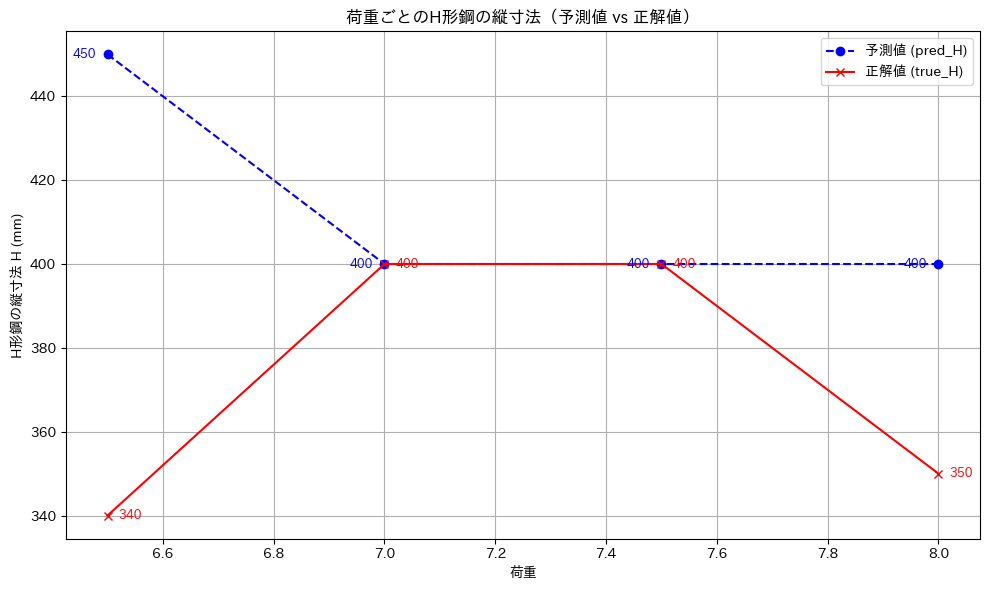

In [40]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# 1. Googleドライブ側の保存先ディレクトリを指定
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)

# 2. グラフのタイトル
graph_title = '荷重ごとのH形鋼の縦寸法（予測値 vs 正解値）'

# 3. 荷重ごとに1点だけ残す
df_h = (
    predictions[
        predictions['section_type'] == 'h'
    ]
    .sort_values('荷重')
    .drop_duplicates(subset=['荷重'])
    .copy()
)

# 4. グラフの描画
plt.figure(figsize=(10, 6))

# 予測値
plt.plot(
    df_h['荷重'],
    df_h['pred_H'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_H)',
)

# 正解値
plt.plot(
    df_h['荷重'],
    df_h['true_H'],
    marker='x',
    linestyle='-',
    color='red',
    label='正解値 (true_H)',
)

# 5. 各点に実際の寸法を表示
for _, row in df_h.iterrows():

    # 予測値
    plt.annotate(
        f"{row['pred_H']:.0f}",
        xy=(row['荷重'], row['pred_H']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # 正解値
    plt.annotate(
        f"{row['true_H']:.0f}",
        xy=(row['荷重'], row['true_H']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )

plt.xlabel('荷重')
plt.ylabel('H形鋼の縦寸法 H (mm)')
plt.title(graph_title)
plt.legend()
plt.grid(True)
plt.tight_layout()

# 6. ファイル名の定義
file_name = f'{graph_title}.png'

# 7. Googleドライブに保存
drive_path = os.path.join(save_dir, file_name)
plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)
print(f'Googleドライブに保存しました: {drive_path}')

# 8. Colabサーバー上にも保存
local_path = os.path.join('/content', file_name)
plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

# 9. PCへダウンロード
files.download(local_path)

plt.show()

##H型鋼の梁と荷重のグラフ作成（誤ったもののみ）

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

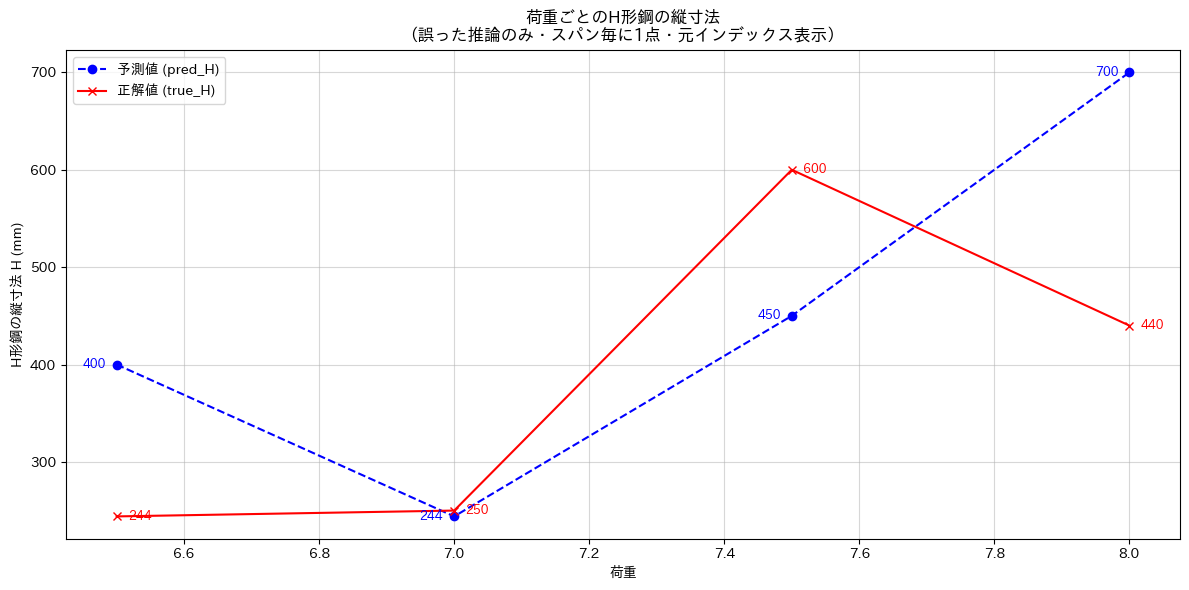

保存しました：/content/drive/MyDrive/research/DNN/Graphs/荷重ごとのH形鋼の縦寸法_誤推論のみ_スパン毎に1点_元インデックス表示.png


In [38]:


# ============================================================
# 1. 保存先ディレクトリの指定と作成
# ============================================================
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 2. H形鋼の誤推論データを抽出
#    ・section_type == 'h'
#    ・荷重で昇順ソート
#    ・各荷重につき1件だけ残す
# ============================================================
df_h = (
    incorrect_predictions[
        incorrect_predictions['section_type'] == 'h'
    ]
    .sort_values('荷重')
    .drop_duplicates(subset=['荷重'])
    .copy()
)


# ============================================================
# 3. グラフ設定
# ============================================================

# グラフタイトル
graph_title = (
    '荷重ごとのH形鋼の縦寸法\n'
    '（誤った推論のみ・スパン毎に1点・元インデックス表示）'
)

# インデックス番号を表示する際のX方向オフセット
offset_x = 0.05

# グラフ作成
plt.figure(figsize=(12, 6))


# ============================================================
# 4. 予測値のプロット
# ============================================================
plt.plot(
    df_h['荷重'],
    df_h['pred_H'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_H)',
)


# ============================================================
# 5. 正解値のプロット
# ============================================================
plt.plot(
    df_h['荷重'],
    df_h['true_H'],
    marker='x',
    linestyle='-',
    color='red',
    label='正解値 (true_H)',
)


# ============================================================
# 6. 各データポイントに実際のH形鋼寸法を表示
# ============================================================
for _, row in df_h.iterrows():

    # 予測値
    plt.annotate(
        f"{row['pred_H']:.0f}",
        xy=(row['荷重'], row['pred_H']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # 正解値
    plt.annotate(
        f"{row['true_H']:.0f}",
        xy=(row['荷重'], row['true_H']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )

# ============================================================
# 7. 軸・タイトル等
# ============================================================
plt.xlabel('荷重')
plt.ylabel('H形鋼の縦寸法 H (mm)')

plt.title(graph_title)

plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()


# ============================================================
# 8. ファイル名の定義
#    \nを含まないファイル名にする
# ============================================================
file_name = (
    '荷重ごとのH形鋼の縦寸法_'
    '誤推論のみ_スパン毎に1点_元インデックス表示.png'
)


# ============================================================
# Google Driveに保存
# ============================================================
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)


# ============================================================
# ColabからPCへダウンロード
# ============================================================
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

files.download(local_path)

plt.show()
print(f'保存しました：{drive_path}')

##BCRの柱のDと荷重のグラフ



Googleドライブに保存しました: /content/drive/MyDrive/research/DNN/Graphs/荷重ごとの柱の幅D（予測値 vs 正解値）.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

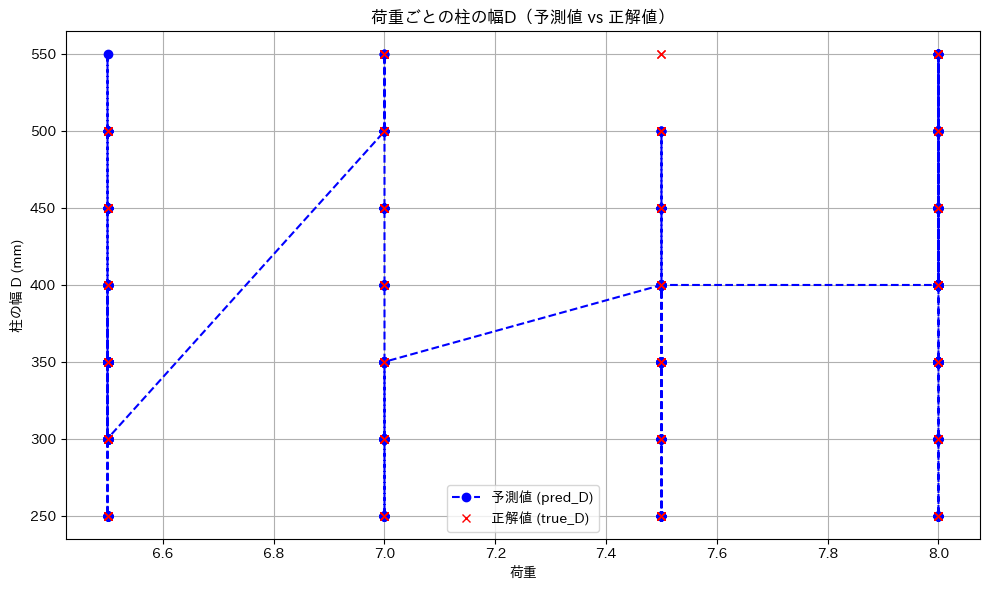

In [33]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. Googleドライブ側の保存先ディレクトリを指定
# ============================================================
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 2. 柱（BOX形鋼）のデータだけを抽出
# ============================================================
df_box = (
    predictions[
        predictions['section_type'] == 'box'
    ]
    .sort_values('荷重')
    .copy()
)


# ============================================================
# 3. グラフのタイトル
# ============================================================
graph_title = '荷重ごとの柱の幅D（予測値 vs 正解値）'


# ============================================================
# 4. グラフの描画
# ============================================================
plt.figure(figsize=(10, 6))


# 予測値
plt.plot(
    df_box['荷重'],
    df_box['pred_D'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_D)',
)


# 正解値
plt.plot(
    df_box['荷重'],
    df_box['true_D'],
    marker='x',
    linestyle='None',
    color='red',
    label='正解値 (true_D)',
)


# ============================================================
# 5. 軸・タイトル等
# ============================================================
plt.xlabel('荷重')
plt.ylabel('柱の幅 D (mm)')
plt.title(graph_title)

plt.legend()
plt.grid(True)

plt.tight_layout()


# ============================================================
# 6. ファイル名
# ============================================================
file_name = f'{graph_title}.png'


# ============================================================
# 7. Google Driveに保存
# ============================================================
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)

print(f'Googleドライブに保存しました: {drive_path}')


# ============================================================
# 8. Colabサーバー上に保存
# ============================================================
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)


# ============================================================
# 9. PCへダウンロード
# ============================================================
files.download(local_path)


# ============================================================
# 10. 表示
# ============================================================
plt.show()

###不正解のもののみをグラフにする。

/tmp/ipykernel_444/431933932.py:143: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

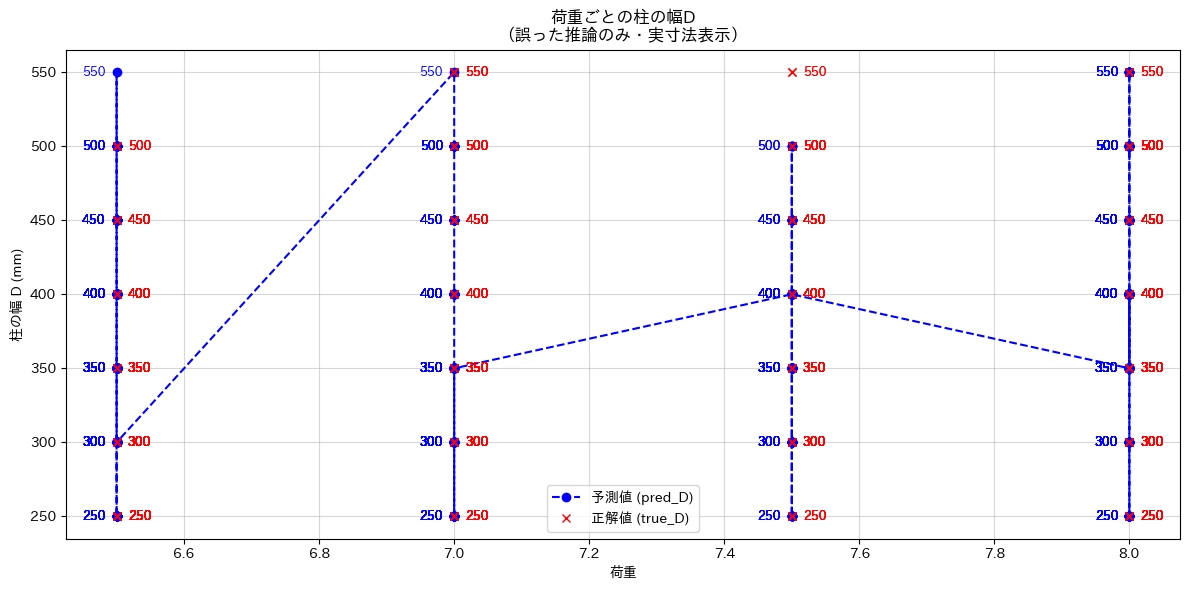

保存しました：/content/drive/MyDrive/research/DNN/Graphs/荷重ごとの柱の幅D_誤推論のみ_実寸法表示.png


In [34]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. 保存先ディレクトリの指定と作成
# ============================================================
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 2. 柱（BOX形鋼）のデータを抽出
#    ・section_type == 'box'
#    ・荷重で昇順ソート
# ============================================================
df_box = (
    incorrect_predictions[
        incorrect_predictions['section_type'] == 'box'
    ]
    .sort_values('荷重')
    .copy()
)


# ============================================================
# 3. グラフ設定
# ============================================================

# グラフタイトル
graph_title = (
    '荷重ごとの柱の幅D\n'
    '（誤った推論のみ・実寸法表示）'
)

# グラフ作成
plt.figure(figsize=(12, 6))


# ============================================================
# 4. 予測値のプロット
# ============================================================
plt.plot(
    df_box['荷重'],
    df_box['pred_D'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_D)',
)


# ============================================================
# 5. 正解値のプロット
# ============================================================
plt.plot(
    df_box['荷重'],
    df_box['true_D'],
    marker='x',
    linestyle='None',
    color='red',
    label='正解値 (true_D)',
)


# ============================================================
# 6. 各データポイントに実際の柱寸法Dを表示
# ============================================================
for _, row in df_box.iterrows():

    # --------------------------------------------------------
    # 予測値
    # --------------------------------------------------------
    plt.annotate(
        f"{row['pred_D']:.0f}",
        xy=(row['荷重'], row['pred_D']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # --------------------------------------------------------
    # 正解値
    # --------------------------------------------------------
    plt.annotate(
        f"{row['true_D']:.0f}",
        xy=(row['荷重'], row['true_D']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )


# ============================================================
# 7. 軸・タイトル等
# ============================================================
plt.xlabel('荷重')
plt.ylabel('柱の幅 D (mm)')

plt.title(graph_title)

plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()


# ============================================================
# 8. ファイル名の定義
#    \nを含まないファイル名にする
# ============================================================
file_name = (
    '荷重ごとの柱の幅D_'
    '誤推論のみ_実寸法表示.png'
)


# ============================================================
# 9. Google Driveに保存
# ============================================================
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)


# ============================================================
# 10. ColabからPCへダウンロード
# ============================================================
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

files.download(local_path)


# ============================================================
# 11. グラフ表示
# ============================================================
plt.show()

print(f'保存しました：{drive_path}')

一点だけ

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

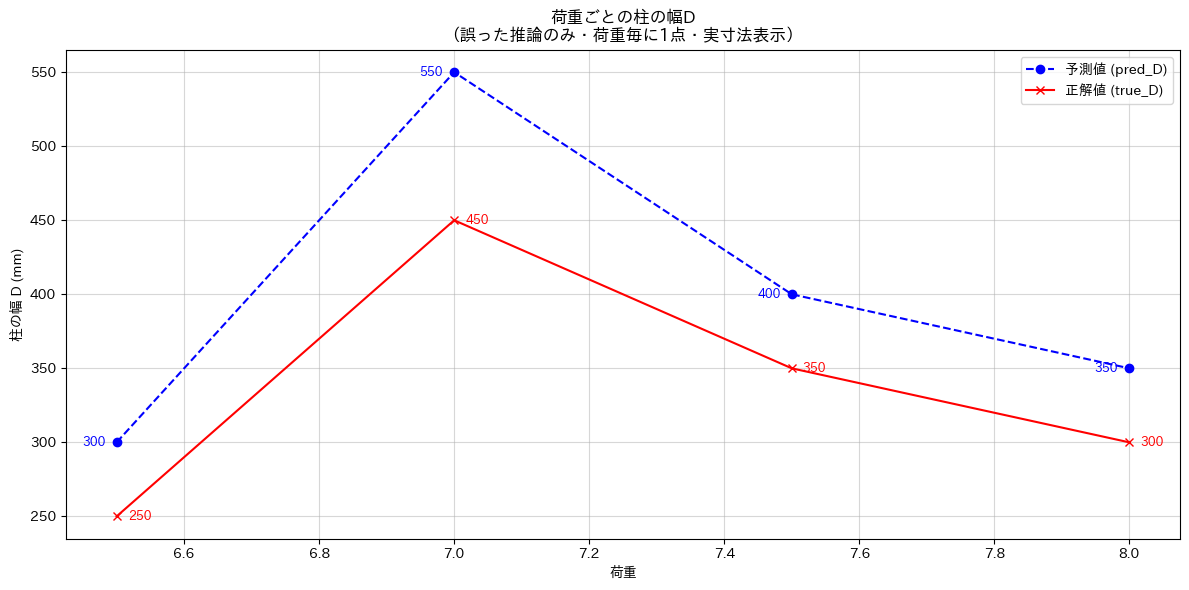

保存しました：/content/drive/MyDrive/research/DNN/Graphs/荷重ごとの柱の幅D_誤推論のみ_荷重毎に1点_実寸法表示.png


In [36]:
import os
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. 保存先ディレクトリの指定と作成
# ============================================================
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)


# ============================================================
# 2. 柱（BOX形鋼）の誤推論データを抽出
#    ・section_type == 'box'
#    ・荷重で昇順ソート
#    ・各荷重につき1件だけ残す
# ============================================================
df_box = (
    incorrect_predictions[
        incorrect_predictions['section_type'] == 'box'
    ]
    .sort_values('荷重')
    .drop_duplicates(subset=['荷重'])
    .copy()
)


# ============================================================
# 3. グラフ設定
# ============================================================
graph_title = (
    '荷重ごとの柱の幅D\n'
    '（誤った推論のみ・荷重毎に1点・実寸法表示）'
)

plt.figure(figsize=(12, 6))


# ============================================================
# 4. 予測値のプロット
# ============================================================
plt.plot(
    df_box['荷重'],
    df_box['pred_D'],
    marker='o',
    linestyle='--',
    color='blue',
    label='予測値 (pred_D)',
)


# ============================================================
# 5. 正解値のプロット
# ============================================================
plt.plot(
    df_box['荷重'],
    df_box['true_D'],
    marker='x',
    linestyle='-',
    color='red',
    label='正解値 (true_D)',
)


# ============================================================
# 6. 各データポイントにD寸法を表示
# ============================================================
for _, row in df_box.iterrows():

    # 予測値
    plt.annotate(
        f"{row['pred_D']:.0f}",
        xy=(row['荷重'], row['pred_D']),
        xytext=(-8, 0),
        textcoords='offset points',
        color='blue',
        fontsize=9,
        va='center',
        ha='right',
        fontweight='bold',
    )

    # 正解値
    plt.annotate(
        f"{row['true_D']:.0f}",
        xy=(row['荷重'], row['true_D']),
        xytext=(8, 0),
        textcoords='offset points',
        color='red',
        fontsize=9,
        va='center',
        ha='left',
        fontweight='bold',
    )


# ============================================================
# 7. 軸・タイトル等
# ============================================================
plt.xlabel('荷重')
plt.ylabel('柱の幅 D (mm)')

plt.title(graph_title)

plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()


# ============================================================
# 8. ファイル名
# ============================================================
file_name = (
    '荷重ごとの柱の幅D_'
    '誤推論のみ_荷重毎に1点_実寸法表示.png'
)


# ============================================================
# 9. Google Driveに保存
# ============================================================
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)


# ============================================================
# 10. ColabからPCへダウンロード
# ============================================================
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

files.download(local_path)


# ============================================================
# 11. グラフ表示
# ============================================================
plt.show()

print(f'保存しました：{drive_path}')

##hとboxでどちらが苦手か？

---



H形鋼 (h) の誤り: 894件 (54.7%)
箱型断面 (box) の誤り: 741件 (45.3%)
総誤り件数: 1635件

Google Driveに保存しました:
/content/drive/MyDrive/research/DNN/Graphs/error_count_and_percentage_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

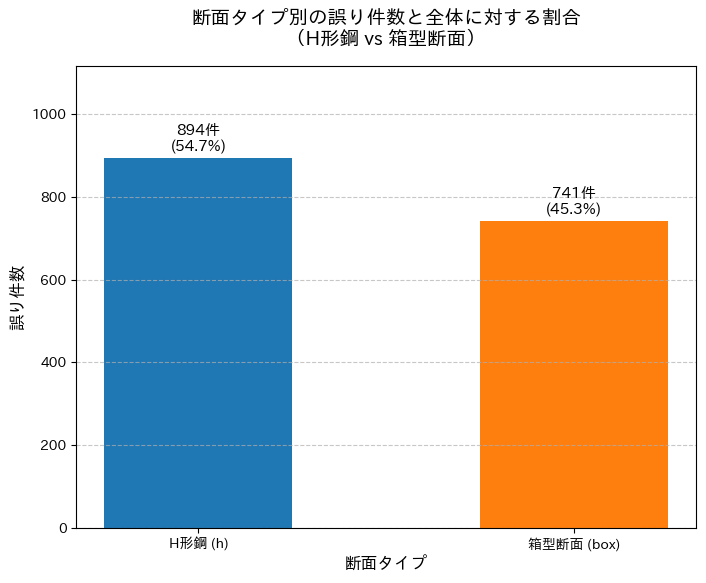

In [46]:


# 1. 保存先ディレクトリの指定と作成
save_dir = '/content/drive/MyDrive/research/DNN/Graphs'
os.makedirs(save_dir, exist_ok=True)

# 2. section_type（'h' と 'box'）ごとの誤り件数と割合を集計
error_counts = incorrect_predictions['section_type'].value_counts()
total_errors = len(incorrect_predictions)

h_count = error_counts.get('h', 0)
box_count = error_counts.get('box', 0)

h_pct = (h_count / total_errors * 100) if total_errors > 0 else 0
box_pct = (box_count / total_errors * 100) if total_errors > 0 else 0

print(f'H形鋼 (h) の誤り: {h_count}件 ({h_pct:.1f}%)')
print(f'箱型断面 (box) の誤り: {box_count}件 ({box_pct:.1f}%)')
print(f'総誤り件数: {total_errors}件')

# 3. 棒グラフの描画
plt.figure(figsize=(8, 6))

sections = ['H形鋼 (h)', '箱型断面 (box)']
counts = [h_count, box_count]
percentages = [h_pct, box_pct]
colors = ['#1f77b4', '#ff7f0e']

bars = plt.bar(
    sections,
    counts,
    color=colors,
    width=0.5
)

# 棒の上に「件数（割合%）」形式でラベルを表示
for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()

    label_text = f'{count}件\n({pct:.1f}%)'

    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + max(counts) * 0.01,
        label_text,
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold',
    )

plt.xlabel('断面タイプ', fontsize=12)
plt.ylabel('誤り件数', fontsize=12)

plt.title(
    '断面タイプ別の誤り件数と全体に対する割合\n（H形鋼 vs 箱型断面）',
    fontsize=14,
    pad=15,
)

# Y軸の範囲
plt.ylim(
    0,
    max(counts) * 1.25 if max(counts) > 0 else 10
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

# 4. ファイル名
file_name = 'error_count_and_percentage_comparison.png'

# 5. Google Driveに保存
drive_path = os.path.join(save_dir, file_name)

plt.savefig(
    drive_path,
    bbox_inches='tight',
    dpi=300
)

print(f'\nGoogle Driveに保存しました:')
print(drive_path)

# 6. Colabの一時領域にも保存
local_path = os.path.join('/content', file_name)

plt.savefig(
    local_path,
    bbox_inches='tight',
    dpi=300
)

# 7. ローカルPCへダウンロード
files.download(local_path)

# 8. グラフを表示
plt.show()

In [47]:
print(drive_path)

/content/drive/MyDrive/research/DNN/Graphs/error_count_and_percentage_comparison.png


#DNN構造をグラフ化する。

In [48]:
# 1. 必要なライブラリのインストール
!pip install torchviz graphviz

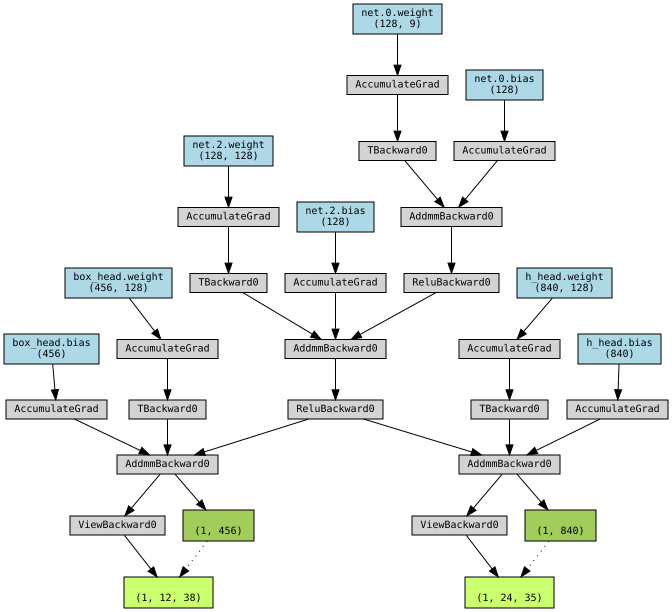

In [49]:
import torch
from torchviz import make_dot

# モデルの最初の層から入力次元数（n_features）とデバイスを自動取得する
n_features = model.net[0].in_features
DEVICE = next(model.parameters()).device

batch_size = 1
dummy_input = torch.randn(batch_size, n_features).to(DEVICE)

# 順伝播を実行
logits_h, logits_box = model(dummy_input)

# ネットワーク図の生成と表示
dot = make_dot((logits_h, logits_box), params=dict(model.named_parameters()))
dot.format = "png"

# Colab上で画像として表示
display(dot)

In [50]:
# 1. 保存するファイル名を指定（拡張子なしで指定すると自動で .png がつきます）
file_path = "simple_dnn3_architecture"
dot.render(file_path, format="png", cleanup=True)

print(f"画像を保存しました: {file_path}.png")

# 2. ColabからローカルPCへファイルを自動ダウンロードする
from google.colab import files
files.download(f"{file_path}.png")

画像を保存しました: simple_dnn3_architecture.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
print(model)

SimpleDNN(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (h_head): Linear(in_features=128, out_features=840, bias=True)
  (box_head): Linear(in_features=128, out_features=456, bias=True)
)


In [52]:
!pip install torchinfo

In [60]:
print(x.shape)

torch.Size([32, 9])


In [55]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 9)
)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleDNN                                [1, 24, 35]               --
├─Sequential: 1-1                        [1, 128]                  --
│    └─Linear: 2-1                       [1, 128]                  1,280
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Linear: 2-3                       [1, 128]                  16,512
│    └─ReLU: 2-4                         [1, 128]                  --
├─Linear: 1-2                            [1, 840]                  108,360
├─Linear: 1-3                            [1, 456]                  58,824
Total params: 184,976
Trainable params: 184,976
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.74
Estimated Total Size (MB): 0.75